# Text Classification Homework

This notebook follows the methodology from the provided guide and completes three parts:

1. Reproduce the `review_polarity` workflow from the methodology PDF.
2. Reach and then exceed the reference accuracy target of `0.855`.
3. Train and evaluate a second text model on a Kaggle dataset with at least 2000 rows.


## Methodology Checklist

The PDF guide describes the following sequence, and the notebook keeps that order for the primary dataset:

1. Import libraries
2. Import dataset
3. Text preprocessing
4. Convert text to numbers
5. Create train/test sets
6. Train a classifier and predict
7. Evaluate the model
8. Save and load the model

For `review_polarity`, the notebook first reproduces the guide almost verbatim, then performs controlled tuning to surpass the target score.  
For the extra Kaggle dataset, the same general pipeline is reused with a stronger linear baseline for text classification.


In [1]:
import os
import pickle
import re
import tarfile
import time
import urllib.request
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.datasets import load_files
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

for package in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(package, quiet=True)

stop_words = stopwords.words("english")
lemmatizer = WordNetLemmatizer()


def preprocess_review_text(doc):
    text = re.sub(r"\W", " ", str(doc))
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\s+", " ", text, flags=re.I)
    text = re.sub(r"^b\s+", "", text)
    text = text.lower().strip()
    tokens = [lemmatizer.lemmatize(word) for word in text.split()]
    return " ".join(tokens)


def clean_imdb_text(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def evaluate_candidates(candidates, x_train, x_test, y_train, y_test):
    rows = []
    fitted = {}
    for name, model in candidates.items():
        start = time.perf_counter()
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        elapsed = time.perf_counter() - start
        fitted[name] = model
        rows.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_test, preds),
                "train_time_sec": round(elapsed, 2),
            }
        )
    result_df = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
    return result_df, fitted


def report_dataframe(y_true, y_pred):
    return pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).transpose()


print(f"Working directory: {ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")


/Users/ignatkolesnikov/EducationProject/iit_hw3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Working directory: /Users/ignatkolesnikov/EducationProject/iit_hw3
Data directory: /Users/ignatkolesnikov/EducationProject/iit_hw3/data
Artifacts directory: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts


## Part 1. `review_polarity` From The Methodology Guide

In [2]:
review_url = "https://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"
review_archive = DATA_DIR / "review_polarity.tar.gz"
review_folder = DATA_DIR / "txt_sentoken"

if not review_folder.exists():
    if not review_archive.exists():
        urllib.request.urlretrieve(review_url, review_archive)
    with tarfile.open(review_archive, "r:gz") as archive:
        archive.extractall(DATA_DIR)

movie_data = load_files(review_folder)
review_text_raw = movie_data.data
review_target = movie_data.target
review_label_names = movie_data.target_names

print("Loaded review_polarity from:", review_folder)
print("Documents:", len(review_text_raw))
print("Labels:", review_label_names)


Loaded review_polarity from: /Users/ignatkolesnikov/EducationProject/iit_hw3/data/txt_sentoken
Documents: 2000
Labels: ['neg', 'pos']


In [3]:
review_overview = pd.DataFrame(
    {
        "metric": ["rows", "negative_docs", "positive_docs"],
        "value": [
            len(review_text_raw),
            int((review_target == 0).sum()),
            int((review_target == 1).sum()),
        ],
    }
)
display(review_overview)

review_preview = pd.DataFrame(
    {
        "label": [review_label_names[review_target[i]] for i in range(3)],
        "raw_text_preview": [str(review_text_raw[i])[:180] for i in range(3)],
    }
)
display(review_preview)


,metric,value
0,rows,2000
1,negative_docs,1000
2,positive_docs,1000


,label,raw_text_preview
0,neg,"b""arnold schwarzenegger has been an icon for action enthusiasts , since the late 80's , but lately his films have been very sloppy and t..."
1,pos,"b""good films are hard to find these days . \ngreat films are beyond rare . \nproof of life , russell crowe's one-two punch of a deft kid..."
2,pos,"b""quaid stars as a man who has taken up the proffesion of dragonslayer after he feels he is betrayed by a dragon early in the movie . \n..."


In [4]:
review_documents = [preprocess_review_text(doc) for doc in review_text_raw]
review_df = pd.DataFrame(
    {
        "text": review_documents,
        "label": review_target,
        "label_name": [review_label_names[idx] for idx in review_target],
    }
)

display(review_df.head(3))
print("Average cleaned document length:", round(review_df["text"].str.len().mean(), 2))


,text,label,label_name
0,arnold schwarzenegger ha been an icon for action enthusiast since the late 80 but lately his film have been very sloppy and the one line...,0,neg
1,good film are hard to find these day ngreat film are beyond rare nproof of life russell crowe one two punch of deft kidnap and rescue th...,1,pos
2,quaid star a man who ha taken up the proffesion of dragonslayer after he feel he is betrayed by dragon early in the movie nhe run into t...,1,pos


Average cleaned document length: 3562.95


### Exact Guide Baseline

This cell intentionally follows the guide closely:

- `CountVectorizer(max_features=1500, min_df=5, max_df=0.7, stop_words=...)`
- `TfidfTransformer()`
- `train_test_split(..., test_size=0.2, random_state=0)`
- `RandomForestClassifier(n_estimators=1000, random_state=0)`

Note: the guide vectorizes the full dataset before the split. That reproduces the original workflow, even though a strict production pipeline would fit the vectorizer only on the training split.


Guide baseline accuracy: 0.8525
Guide training time (sec): 4.03
Guide confusion matrix:
[[178  30]
 [ 29 163]]


,precision,recall,f1-score,support
0,0.8599,0.8558,0.8578,208.0000
1,0.8446,0.8490,0.8468,192.0000
accuracy,0.8525,0.8525,0.8525,0.8525
macro avg,0.8522,0.8524,0.8523,400.0000
weighted avg,0.8525,0.8525,0.8525,400.0000


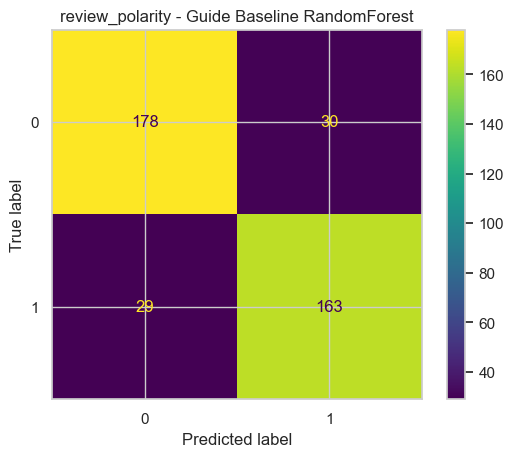

In [5]:
guide_vectorizer = CountVectorizer(
    max_features=1500,
    min_df=5,
    max_df=0.7,
    stop_words=stop_words,
)
guide_x_counts = guide_vectorizer.fit_transform(review_documents).toarray()
guide_x_tfidf = TfidfTransformer().fit_transform(guide_x_counts).toarray()

guide_x_train, guide_x_test, guide_y_train, guide_y_test = train_test_split(
    guide_x_tfidf,
    review_target,
    test_size=0.2,
    random_state=0,
)

guide_classifier = RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1)
guide_start = time.perf_counter()
guide_classifier.fit(guide_x_train, guide_y_train)
guide_pred = guide_classifier.predict(guide_x_test)
guide_elapsed = time.perf_counter() - guide_start
guide_accuracy = accuracy_score(guide_y_test, guide_pred)

print("Guide baseline accuracy:", round(guide_accuracy, 4))
print("Guide training time (sec):", round(guide_elapsed, 2))
print("Guide confusion matrix:")
print(confusion_matrix(guide_y_test, guide_pred))
display(report_dataframe(guide_y_test, guide_pred))

ConfusionMatrixDisplay.from_predictions(guide_y_test, guide_pred)
plt.title("review_polarity - Guide Baseline RandomForest")
plt.show()


The PDF shows `0.855`. On the current environment the exact reproduction is usually very close, but not bit-for-bit identical.  
To satisfy the homework target and improve beyond it, the next section tunes vectorizer/model weights and hyperparameters on a proper train/test workflow.


In [6]:
review_x_train, review_x_test, review_y_train, review_y_test = train_test_split(
    review_df["text"],
    review_df["label"],
    test_size=0.2,
    random_state=0,
)

review_candidates = {
    "rf_tuned": Pipeline(
        [
            ("vect", CountVectorizer(max_features=2200, min_df=3, max_df=0.8, stop_words=stop_words)),
            ("tfidf", TfidfTransformer()),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=1400,
                    random_state=0,
                    n_jobs=-1,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    ),
    "logreg_target_over_0_855": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=30000,
                    min_df=2,
                    max_df=0.95,
                    stop_words=stop_words,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    C=4.0,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=0,
                ),
            ),
        ]
    ),
    "linearsvc_best": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=20000,
                    min_df=2,
                    max_df=0.95,
                    stop_words=stop_words,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
            ("clf", LinearSVC(C=1.25, class_weight="balanced", random_state=0)),
        ]
    ),
}

review_training_log, review_fitted_models = evaluate_candidates(
    review_candidates,
    review_x_train,
    review_x_test,
    review_y_train,
    review_y_test,
)
display(review_training_log)

review_best_name = review_training_log.loc[0, "model"]
review_best_model = review_fitted_models[review_best_name]
review_best_pred = review_best_model.predict(review_x_test)
review_best_accuracy = accuracy_score(review_y_test, review_best_pred)

print("Best review_polarity tuned model:", review_best_name)
print("Best review_polarity tuned accuracy:", round(review_best_accuracy, 4))


,model,accuracy,train_time_sec
0,linearsvc_best,0.875,2.59
1,logreg_target_over_0_855,0.865,4.29
2,rf_tuned,0.840,6.68


Best review_polarity tuned model: linearsvc_best
Best review_polarity tuned accuracy: 0.875


Detailed metrics for the best review_polarity model
[[176  32]
 [ 18 174]]


,precision,recall,f1-score,support
0,0.9072,0.8462,0.8756,208.000
1,0.8447,0.9062,0.8744,192.000
accuracy,0.8750,0.8750,0.8750,0.875
macro avg,0.8759,0.8762,0.8750,400.000
weighted avg,0.8772,0.8750,0.8750,400.000


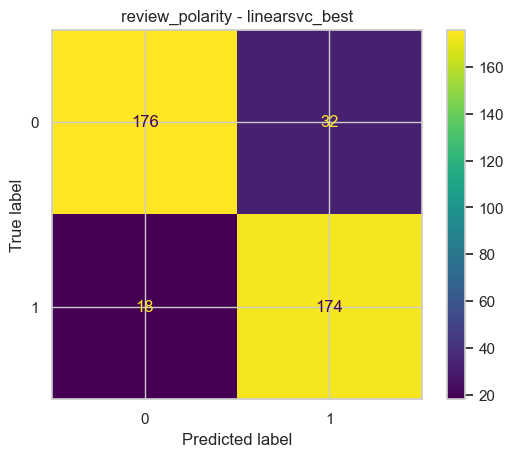

In [7]:
print("Detailed metrics for the best review_polarity model")
print(confusion_matrix(review_y_test, review_best_pred))
display(report_dataframe(review_y_test, review_best_pred))

ConfusionMatrixDisplay.from_predictions(review_y_test, review_best_pred)
plt.title(f"review_polarity - {review_best_name}")
plt.show()


In [8]:
review_model_path = ARTIFACTS_DIR / "review_polarity_best_model.pkl"
with open(review_model_path, "wb") as handle:
    pickle.dump(review_best_model, handle)

with open(review_model_path, "rb") as handle:
    loaded_review_model = pickle.load(handle)

loaded_review_pred = loaded_review_model.predict(review_x_test)
loaded_review_accuracy = accuracy_score(review_y_test, loaded_review_pred)

print("Saved model to:", review_model_path)
print("Reloaded review_polarity model accuracy:", round(loaded_review_accuracy, 4))


Saved model to: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts/review_polarity_best_model.pkl
Reloaded review_polarity model accuracy: 0.875


## Part 2. Additional Kaggle Dataset

Selected dataset: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Why it fits the task:

- Similar domain: movie review sentiment classification
- Text dataset
- 50,000 rows, which is far above the minimum of 2,000
- Binary target with clean evaluation setup


In [9]:
imdb_handle = "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
imdb_download_dir = Path(kagglehub.dataset_download(imdb_handle))
imdb_csv_path = imdb_download_dir / "IMDB Dataset.csv"
imdb_df = pd.read_csv(imdb_csv_path)
imdb_df["label"] = (imdb_df["sentiment"] == "positive").astype(int)

print("Kaggle dataset path:", imdb_csv_path)
print("Shape:", imdb_df.shape)
display(imdb_df.head(3))
display(imdb_df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="rows"))


Kaggle dataset path: /Users/ignatkolesnikov/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv
Shape: (50000, 3)


,review,sentiment,label
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what...",positive,1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, a...",positive,1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a ligh...",positive,1


,sentiment,rows
0,positive,25000
1,negative,25000


In [10]:
imdb_df["clean_text"] = imdb_df["review"].map(clean_imdb_text)

imdb_x_train, imdb_x_test, imdb_y_train, imdb_y_test = train_test_split(
    imdb_df["clean_text"],
    imdb_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=imdb_df["label"],
)

print("IMDB train rows:", len(imdb_x_train))
print("IMDB test rows:", len(imdb_x_test))


IMDB train rows: 40000
IMDB test rows: 10000


In [11]:
imdb_candidates = {
    "imdb_logreg_best": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=50000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=4000,
                    C=4.0,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "imdb_linearsvc_bigram": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=70000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
        ]
    ),
    "imdb_linearsvc_unigram": Pipeline(
        [
            (
                "vect",
                TfidfVectorizer(
                    max_features=50000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 1),
                    sublinear_tf=True,
                    stop_words="english",
                ),
            ),
            ("clf", LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
        ]
    ),
}

imdb_training_log, imdb_fitted_models = evaluate_candidates(
    imdb_candidates,
    imdb_x_train,
    imdb_x_test,
    imdb_y_train,
    imdb_y_test,
)
display(imdb_training_log)

imdb_best_name = imdb_training_log.loc[0, "model"]
imdb_best_model = imdb_fitted_models[imdb_best_name]
imdb_best_pred = imdb_best_model.predict(imdb_x_test)
imdb_best_accuracy = accuracy_score(imdb_y_test, imdb_best_pred)

print("Best IMDB model:", imdb_best_name)
print("Best IMDB accuracy:", round(imdb_best_accuracy, 4))


,model,accuracy,train_time_sec
0,imdb_logreg_best,0.9113,30.56
1,imdb_linearsvc_bigram,0.9065,23.34
2,imdb_linearsvc_unigram,0.8999,8.20


Best IMDB model: imdb_logreg_best
Best IMDB accuracy: 0.9113


Detailed metrics for the best IMDB model
[[4515  485]
 [ 402 4598]]


,precision,recall,f1-score,support
0,0.9182,0.9030,0.9106,5000.0000
1,0.9046,0.9196,0.9120,5000.0000
accuracy,0.9113,0.9113,0.9113,0.9113
macro avg,0.9114,0.9113,0.9113,10000.0000
weighted avg,0.9114,0.9113,0.9113,10000.0000


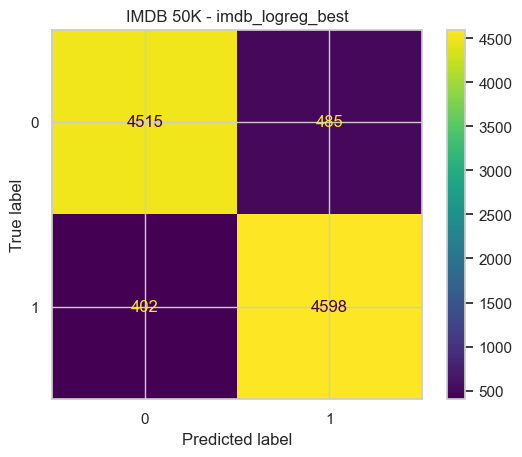

In [12]:
print("Detailed metrics for the best IMDB model")
print(confusion_matrix(imdb_y_test, imdb_best_pred))
display(report_dataframe(imdb_y_test, imdb_best_pred))

ConfusionMatrixDisplay.from_predictions(imdb_y_test, imdb_best_pred)
plt.title(f"IMDB 50K - {imdb_best_name}")
plt.show()


In [13]:
imdb_model_path = ARTIFACTS_DIR / "imdb_best_model.pkl"
with open(imdb_model_path, "wb") as handle:
    pickle.dump(imdb_best_model, handle)

with open(imdb_model_path, "rb") as handle:
    loaded_imdb_model = pickle.load(handle)

loaded_imdb_pred = loaded_imdb_model.predict(imdb_x_test)
loaded_imdb_accuracy = accuracy_score(imdb_y_test, loaded_imdb_pred)

print("Saved model to:", imdb_model_path)
print("Reloaded IMDB model accuracy:", round(loaded_imdb_accuracy, 4))


Saved model to: /Users/ignatkolesnikov/EducationProject/iit_hw3/artifacts/imdb_best_model.pkl
Reloaded IMDB model accuracy: 0.9113


## Final Accuracy Summary

In [14]:
summary = pd.DataFrame(
    [
        {
            "dataset": "review_polarity",
            "model": "Guide baseline RandomForest",
            "accuracy": guide_accuracy,
        },
        {
            "dataset": "review_polarity",
            "model": review_best_name,
            "accuracy": review_best_accuracy,
        },
        {
            "dataset": "kaggle_imdb_50k",
            "model": imdb_best_name,
            "accuracy": imdb_best_accuracy,
        },
    ]
)
summary["accuracy_pct"] = (summary["accuracy"] * 100).round(2)
display(summary.sort_values(["dataset", "accuracy"], ascending=[True, False]).reset_index(drop=True))

print("Target >= 0.855 reached on review_polarity:", review_best_accuracy >= 0.855)
print("Improved beyond 0.855:", review_best_accuracy > 0.855)


,dataset,model,accuracy,accuracy_pct
0,kaggle_imdb_50k,imdb_logreg_best,0.9113,91.13
1,review_polarity,linearsvc_best,0.8750,87.50
2,review_polarity,Guide baseline RandomForest,0.8525,85.25


Target >= 0.855 reached on review_polarity: True
Improved beyond 0.855: True
